## Imports

In [22]:
#pip install seaborn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 


sns.__version__


'0.13.2'

### Initial Look at the data 

In [23]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [24]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Cleaning the data 

### Are there any duplicates

- Yes there are 107 duplicates overall


In [25]:
duplicates = titanic.duplicated().sum()
duplicates


107

In [26]:
titanic.drop_duplicates(inplace=True)
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [27]:
null = titanic.isnull().sum()
null


survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [28]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic = titanic.drop(columns=['deck'])



### Data is clean

In [29]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [30]:
##Average fare and age per class

titanic.groupby('class')[['fare', 'age']].mean()


/var/folders/8y/4_g5hd914lsg0_ml4z46p08h0000gn/T/ipykernel_17680/584922901.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')[['fare', 'age']].mean()


,fare,age
class,,
First,84.487812,36.947056
Second,21.835404,29.838364
Third,13.656223,25.718321


##Add a new column showing the fare as a percentage of total

In [31]:
titanic['fare % of total'] = (titanic['fare'] / titanic['fare'].sum()) * 100
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,fare % of total
0,0,3,male,22.00,1,0,7.2500,S,Third,man,True,Southampton,no,False,0.026641
1,1,1,female,38.00,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,0.261936
2,1,3,female,26.00,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0.029121
3,1,1,female,35.00,1,0,53.1000,S,First,woman,False,Southampton,yes,False,0.195120
4,0,3,male,35.00,0,0,8.0500,S,Third,man,True,Southampton,no,True,0.029580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.00,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False,0.107022
887,1,1,female,19.00,0,0,30.0000,S,First,woman,False,Southampton,yes,True,0.110237
888,0,3,female,28.25,1,2,23.4500,S,Third,woman,False,Southampton,no,False,0.086169
889,1,1,male,26.00,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,0.110237


## Survivors Male/Female 

In [32]:
titanic.groupby('sex')['survived'].sum()

sex
female    217
male      106
Name: survived, dtype: int64

##Intresting insights 

In [33]:
titanic.groupby('class')['survived'].sum()

/var/folders/8y/4_g5hd914lsg0_ml4z46p08h0000gn/T/ipykernel_17680/3947101243.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('class')['survived'].sum()


class
First     135
Second     84
Third     104
Name: survived, dtype: int64

In [34]:
male_survivors = titanic.groupby('adult_male')['survived'].sum()

# Data Visualisation

### Age Frequency 

<Axes: ylabel='Frequency'>

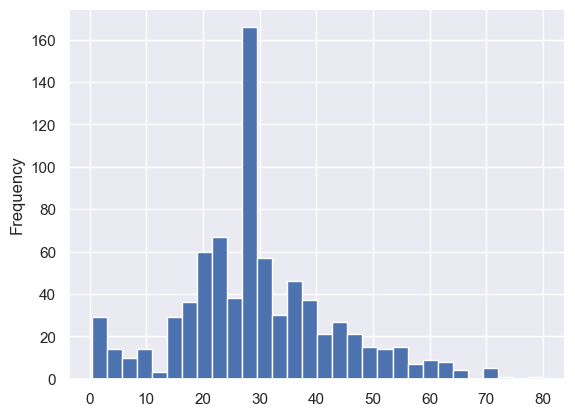

In [35]:
titanic['age'].plot(kind='hist', bins=30)



Text(0, 0.5, 'Survival Rate')

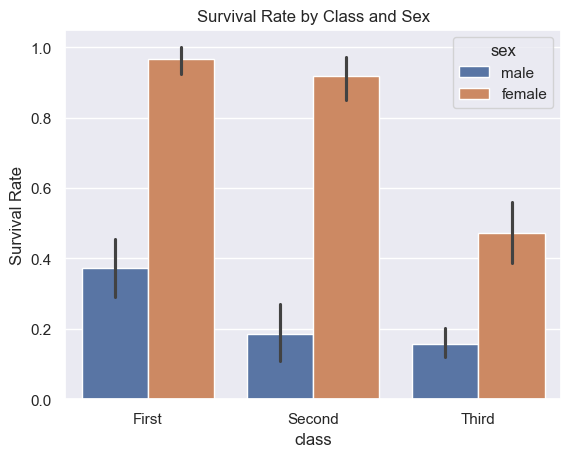

In [41]:
sns.barplot(data=titanic, x='class', y='survived', hue='sex')
plt.title('Survival Rate by Class and Sex')
plt.ylabel('Survival Rate')


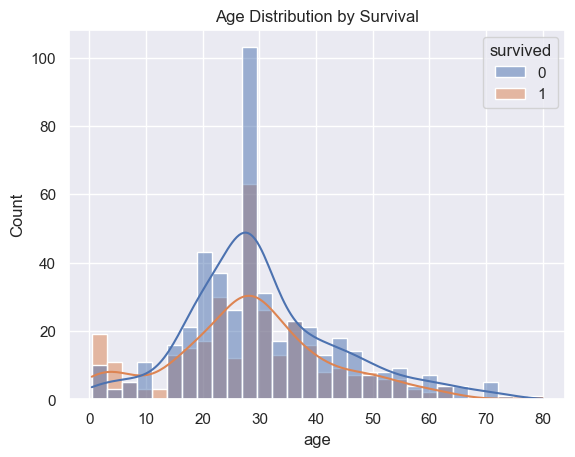

In [42]:
sns.histplot(data=titanic, x='age', hue='survived', kde=True, bins=30)
plt.title('Age Distribution by Survival')
plt.show()

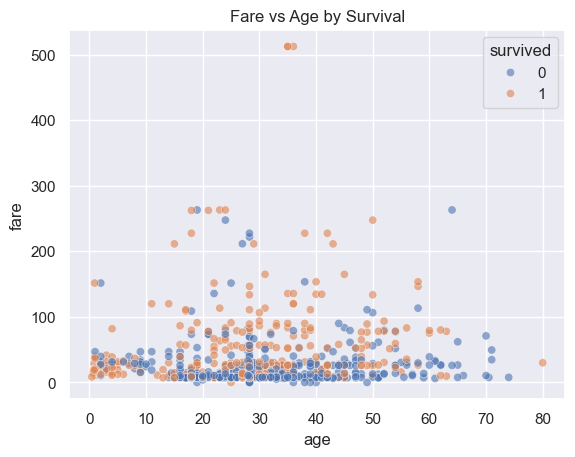

In [43]:
sns.scatterplot(data=titanic, x='age', y='fare', hue='survived', alpha=0.6)
plt.title('Fare vs Age by Survival')
plt.show()

Text(0.5, 1.0, 'Fare Distribution by Class')

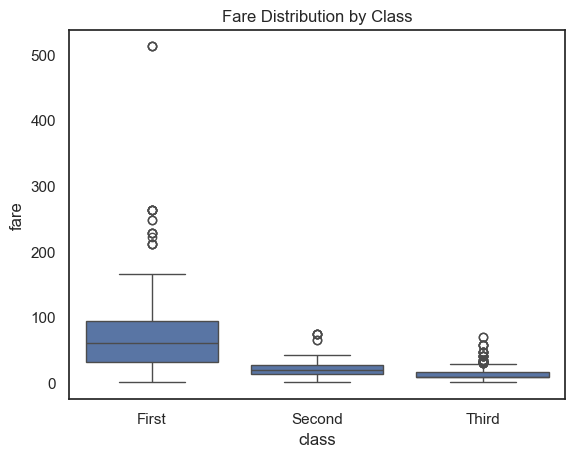

In [56]:
sns.boxplot(data=titanic, x='class', y='fare')
plt.title('Fare Distribution by Class')



Text(0.5, 0, 'emabrkment town')

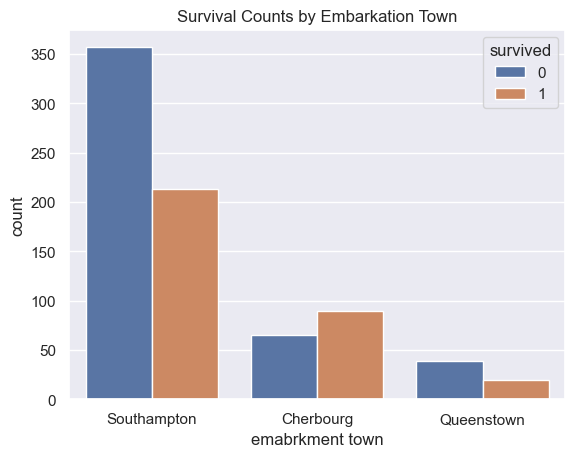

In [48]:
sns.countplot(data=titanic, x='embark_town', hue='survived')
plt.title('Survival Counts by Embarkation Town')
plt.xlabel("emabrkment town")


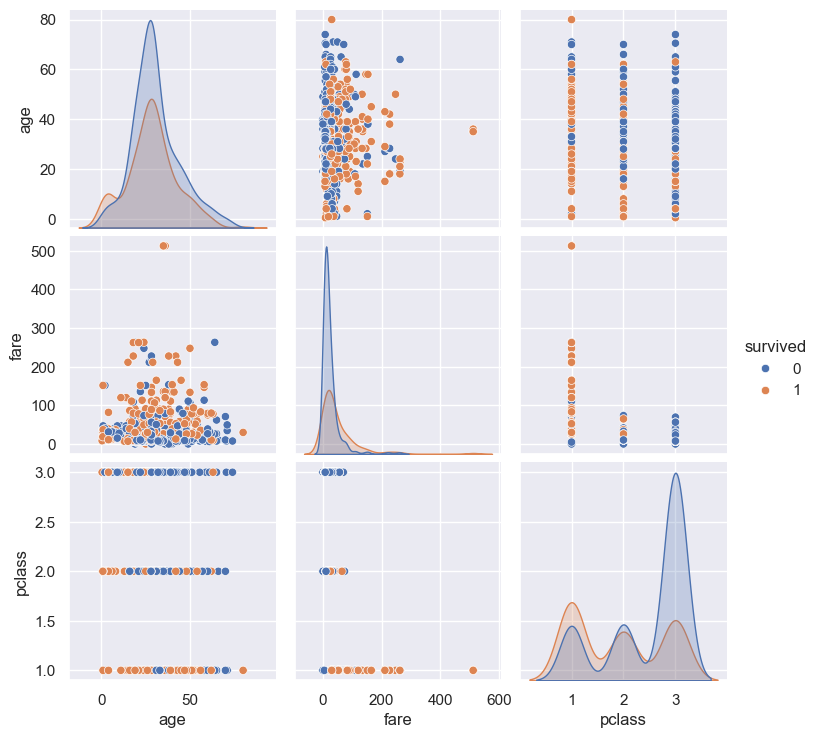

In [52]:
sns.pairplot(titanic[['survived', 'age', 'fare', 'pclass']], hue='survived')


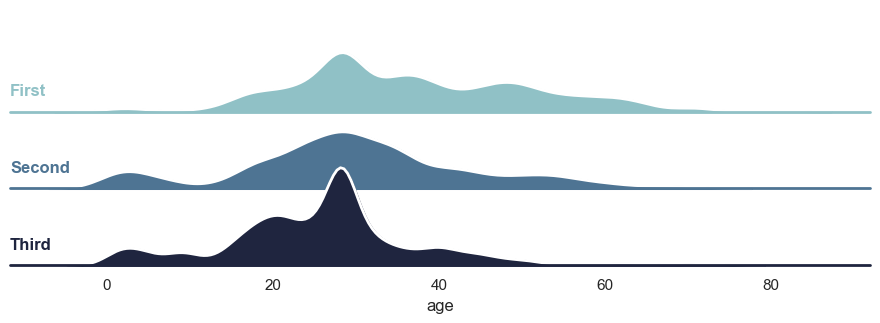

In [53]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

pal = sns.cubehelix_palette(3, rot=-.25, light=.7)
g = sns.FacetGrid(titanic, row="class", hue="class", aspect=8, height=1.2, palette=pal)

g.map(sns.kdeplot, "age", bw_adjust=0.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "age", clip_on=False, color="w", lw=2, bw_adjust=0.5)
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)

g.map(label, "age")

g.figure.subplots_adjust(hspace=-.25)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.show()